In [ ]:
import os
import math
import numpy as np
import xarray as xr
import scipy.ndimage
from pathlib import Path
import netCDF4 as nc
import time
import sys
import multiprocessing
import json
import gc
import argparse

t=82
t_new = 0
dilation_const = 1
max_entrainment_magnitude = 1e30

def dilate_mask(source, dilateAmount):
    if np.any(source) and dilateAmount > 0:

        expansion = np.zeros((3,3,3), dtype=bool)
        expansion[1, 1, :] = True  # X axis
        expansion[1, :, 1] = True  # Y axis
        expansion[:, 1, 1] = True  # Z axis

        for _ in range(dilateAmount):
            padded = np.pad(source, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
            padded = np.pad(padded, ((0, 0), (1, 1), (1, 1)), mode='wrap')
            dilated = scipy.ndimage.binary_dilation(padded, structure=expansion)
            unpadded_dilated = dilated[1:-1, 1:-1, 1:-1]
        return unpadded_dilated
    else:
        return source

In [ ]:
source_input_dir = Path("/mnt/stor-pool-01/projects/heus/BNF/Ensemble_Tests/512_512_50m_12km_chbuff/2025-07-01_normal_shell/thijs")
output_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS")

paths = {
        "netE": source_input_dir / "netE.nc",
        "cloud_labels": output_dir / "cloud_labels.nc",
        "combined_labels": output_dir / "combined_labels.nc",
        "shell_labels": output_dir / "shell_labels.nc",
    }

In [ ]:
with xr.open_dataset(paths["cloud_labels"], decode_times=False) as ds_cloud:
    cloud_labels = ds_cloud.cloud_labels.isel(time=t_new).values
    
with xr.open_dataset(paths["combined_labels"], decode_times=False) as ds_comb:
    combined_labels = ds_comb.labels.isel(time=t_new).values
    
with xr.open_dataset(paths["shell_labels"], decode_times=False) as ds_shell:
    shell_labels = ds_shell.shell_labels.isel(time=t_new).values

# pre-allocate sets
nz, ny, nx = cloud_labels.shape
out_shell_label_ent = np.zeros((nz, ny, nx), dtype=np.float32)
out_cloud_label_ent = np.zeros((nz, ny, nx), dtype=np.float32)
total_shell_ent_profile = np.zeros(nz, dtype=np.float32)
total_cloud_ent_profile = np.zeros(nz, dtype=np.float32)

with xr.open_dataset(paths["netE"], decode_times=False) as ds_e:
    # Helper inline function to slice and filter on the fly
    def load_and_filter(var_name):
        sliced = ds_e[var_name].isel(time=t)
        return xr.where(abs(sliced) < max_entrainment_magnitude, sliced, np.nan).values

    cloud_e_x = load_and_filter("netE_flux_x_ql")
    cloud_e_y = load_and_filter("netE_flux_y_ql")
    cloud_e_z = load_and_filter("netE_flux_z_ql")

    shell_e_x = load_and_filter("netE_flux_x_shell")
    shell_e_y = load_and_filter("netE_flux_y_shell")
    shell_e_z = load_and_filter("netE_flux_z_shell")

In [ ]:
# ----------------------------------------------------------------------
# Step 1 - Shell Entrainment (Accumulates Shell Fluxes near Cloud Edges)
# ----------------------------------------------------------------------

# -- Iterate through shell
shell_list = np.unique(shell_labels)
shell_list = shell_list[shell_list != 0]

for label_i in shell_list:

    # obtain combined mask for that shell index
    label_mask = (combined_labels == label_i)

    # Iterate through each cloud
    contained_cloud_list = np.unique(cloud_labels[label_mask])
    contained_cloud_list = contained_cloud_list[contained_cloud_list != 0]

    if len(contained_cloud_list) == 0:
        continue

    combined_cloud_mask = np.isin(cloud_labels, contained_cloud_list)

    dilated_clouds = dilate_mask(combined_cloud_mask, dilation_const)

    if not np.any(dilated_clouds):
        continue

    e_x_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=2)
    e_y_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=1)
    e_z_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=0)
    e_z_mask[0, :, :] = dilated_clouds[0, :, :] # prevent rolling along boundary

    # sum x and y
    sum_x = np.nansum(shell_e_x * e_x_mask, axis=(1, 2))
    sum_y = np.nansum(shell_e_y * e_y_mask, axis=(1, 2))

    shell_target = (shell_labels == label_i)
    shell_above = shell_target
    shell_below = np.zeros_like(shell_target)
    shell_below[1:] = shell_target[:-1]

    case1_mask = e_z_mask & shell_above & ~shell_below # case 1: shell above but not below
    case2_mask = e_z_mask & shell_below & ~shell_above # case 2: shell below but not above

    # sum z
    sum_z_case1 = np.nansum(shell_e_z * case1_mask, axis=(1, 2))
    sum_z_case2 = np.nansum(shell_e_z * case2_mask, axis=(1, 2))

    sum_z = np.zeros(nz, dtype=np.float32)
    sum_z += sum_z_case1
    sum_z[:-1] += sum_z_case2[1:]  # Shift map back down safely

    # apply sums
    sum_total = (sum_x + sum_y + sum_z)
    broadcasted_sum = sum_total[:, np.newaxis, np.newaxis]

    out_shell_label_ent += broadcasted_sum * label_mask
    total_shell_ent_profile += sum_total
    

# ----------------------------------------------------------------------
# Step 2 - Cloud Entrainment (Accumulates Cloud Fluxes near Shell Edges)
# ----------------------------------------------------------------------
cloud_list = np.unique(cloud_labels)
cloud_list = cloud_list[cloud_list != 0]

for c_label_i in cloud_list:
    cloud_target = (cloud_labels == c_label_i)

    # Finds the index of the very first True value in the cloud mask
    first_idx = np.argmax(cloud_target) 
    label_i = combined_labels.flat[first_idx]
    if label_i == 0:
        continue

    current_shell = (shell_labels == label_i)
    if not np.any(current_shell):
        continue

    dilated_shell = dilate_mask(current_shell, dilation_const)
    if not np.any(dilated_shell):
        continue

    e_x_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=2)
    e_y_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=1)
    e_z_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=0)
    e_z_mask[0, :, :] = dilated_shell[0, :, :] # prevent rolling along boundary

    # sum x,y
    sum_x = np.nansum(cloud_e_x * e_x_mask, axis=(1, 2))
    sum_y = np.nansum(cloud_e_y * e_y_mask, axis=(1, 2))

    cloud_above = cloud_target
    cloud_below = np.zeros_like(cloud_target)
    cloud_below[1:] = cloud_target[:-1]

    case1_mask = e_z_mask & cloud_above & ~cloud_below # case 1: shell above but not below
    case2_mask = e_z_mask & cloud_below & ~cloud_above # case 2: shell below but not above

    sum_z_case1 = np.nansum(cloud_e_z * case1_mask, axis=(1, 2))
    sum_z_case2 = np.nansum(cloud_e_z * case2_mask, axis=(1, 2))

    sum_z = np.zeros(nz, dtype=np.float32)
    sum_z += sum_z_case1
    sum_z[:-1] += sum_z_case2[1:]

    sum_total = (sum_x + sum_y + sum_z)
    broadcasted_sum = sum_total[:, np.newaxis, np.newaxis]

    out_cloud_label_ent += broadcasted_sum * cloud_target
    total_cloud_ent_profile += sum_total

In [5]:
np.unique(shell_e_x)

array([-3110.05  , -2892.365 , -2878.1929, ...,  7641.878 ,  7722.0537,
              nan], dtype=float32)

In [7]:
sliced = ds_e["netE_flux_y_shell"].isel(time=t)
np.unique(sliced)

array([-11891.823  , -11717.267  , -11539.36   , ...,    731.01184,
          754.1712 ,          nan], dtype=float32)

In [11]:
np.unique(total_shell_ent_profile)

array([0.], dtype=float32)

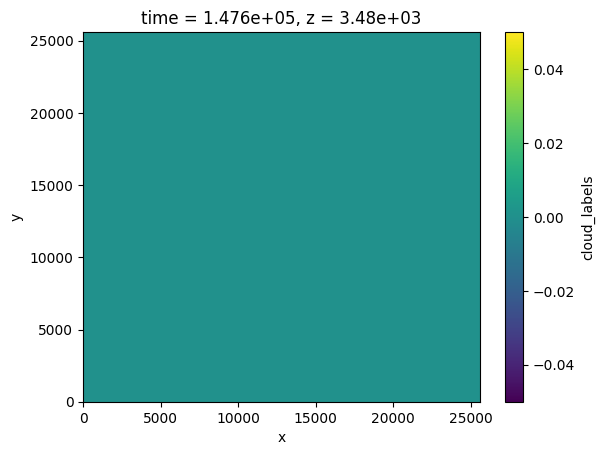

In [23]:
ds_cloud = xr.open_dataset(paths["cloud_labels"], decode_times=False)
ds_cloud.cloud_labels.isel(time=0, z=89).plot(x="x",y="y")

In [25]:
np.unique(ds_cloud.cloud_labels.isel(time=1))

array([0], dtype=uint32)